<a href="https://colab.research.google.com/github/kondapalliDeepa/FMML_M1L1/blob/main/Copy_of_FMML_Module4_Lab3_June2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FOUNDATIONS OF MODERN MACHINE LEARNING, IIIT Hyderabad
# Module 4: Perceptron and Gradient Descent
## Lab 3: Gradient Descent

Gradient descent is a very important algorithm to understand, as it underpins many of the more advanced algorithms used in Machine Learning and Deep Learning.

A brief overview of the algorithm is


*   start with a random initialization of the solution.
*   incrementally change the solution by moving in the direction of negative gradient of the objective function.
*   repeat the previous step until some convergence criteria is met.

The key equation for change in weight is:
$$w^{k+1} \leftarrow w^k - \eta \Delta J$$

In this lab, we will discuss stochastic gradient descent, mini-batch gradient descent and batch gradient descent.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

# Creating the Data

Let's generate some data with:
\begin{equation} y_0= 4 \end{equation}
\begin{equation} y_1= 3 \end{equation}

and also add some noise to the data.

In [4]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

Let's also plot the data we just created

Text(0, 0.5, 'y')

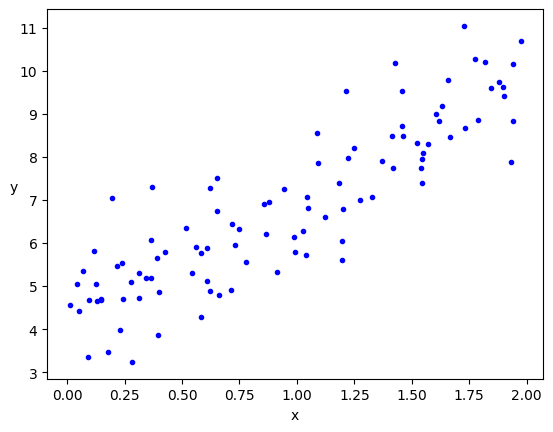

In [5]:
plt.plot(X, y, 'b.')
plt.xlabel('x')
plt.ylabel('y', rotation=0)

## Cost Function

The equation for calculating cost function is as shown below. The cost function is only for linear regression. For other algorithms, the cost function will be different and the gradients would have to be derived from the cost functions

\begin{equation}
J(y_{pred}) = \frac{1}{2} m \sum_{i=1}^{m} (h(y_{pred})^{(i)} - y^{(i)})^2
\end{equation}

In [6]:
def cal_cost(y_pred, X, y):
    '''
    Calculates the cost for given X and Y.
    y_pred = Vector of y_preds
    X = Row of X's np.zeros((2, j))
    y = Actual y's np.zeros((2, 1))

    where:
        j is the no of features
    '''

    m = len(y)

    predictions = X.dot(y_pred)
    cost = (1 / 2 * m) * np.sum(np.square(predictions - y))

    return cost

## Gradients

\begin{equation}
y_{pred_0}: = y_{pred_0} -\alpha . (1/m .\sum_{i=1}^{m}(h(y_{pred}^{(i)} - y^{(i)}).X_0^{(i)})
\end{equation}
\begin{equation}
y_{pred_1}: = y_{pred_1} -\alpha . (1/m .\sum_{i=1}^{m}(h(y_{pred}^{(i)} - y^{(i)}).X_0^{(i)})
\end{equation}
.

.

.

.

\begin{equation}
y_{pred_j}: = y_{pred_j} -\alpha . (1/m .\sum_{i=1}^{m}(h(y_{pred}^{(i)} - y^{(i)}).X_0^{(i)})
\end{equation}

In [7]:
def gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=100):
    '''
    X = Matrix of X with added bias units
    y = Vector of Y
    y_pred = Vector of y_preds np.random.randn(j, 1)
    learning_rate
    iterations = no of iterations

    Returns the final y_pred vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)
    y_pred_history = np.zeros((iterations, 2))

    for it in range(iterations):
        prediction = np.dot(X, y_pred)
        y_pred = y_pred - (1 / m) * learning_rate * (X.T.dot((prediction - y)))
        y_pred_history[it,:] = y_pred.T
        cost_history[it]  = cal_cost(y_pred, X, y)

    return y_pred, cost_history, y_pred_history

Let's do 1000 iterations with a learning rate of 0.01.
We will start with a random prediction.

In [8]:
lr = 0.01
n_iter = 1000

y_pred = np.random.randn(2,1)
X_b = np.c_[np.ones((len(X), 1)), X]
y_pred, cost_history, y_pred_history = gradient_descent(X_b, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 3.903
y_pred[1]: 3.046
Final error: 4180.375


Plotting the error vs Number of iterations

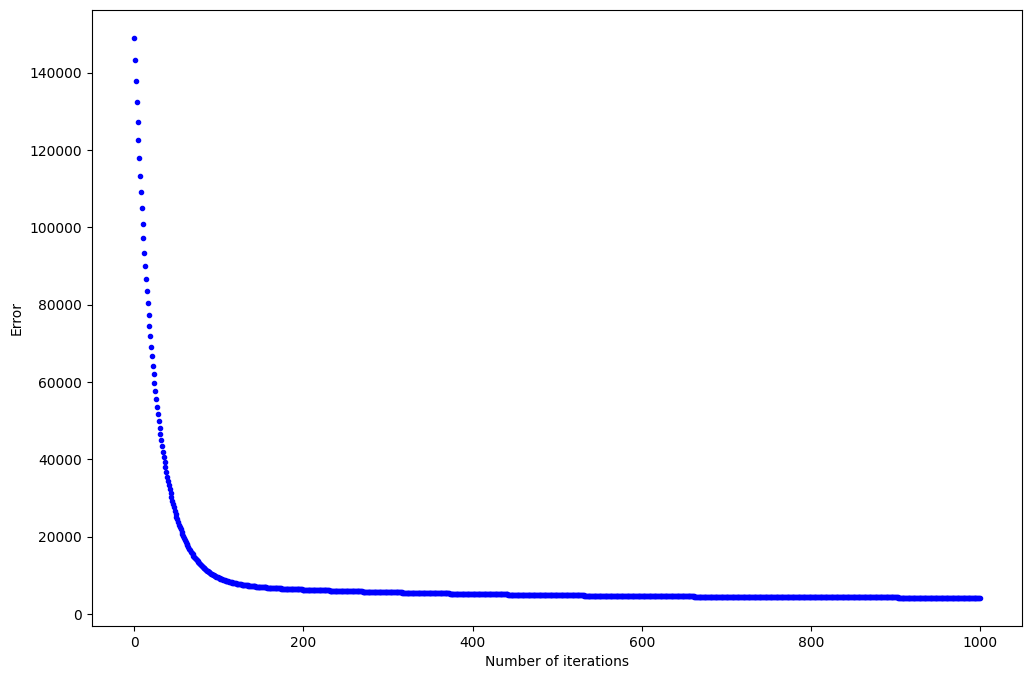

In [9]:
fig, ax = plt.subplots(figsize=(12,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')

ax.plot(range(n_iter), cost_history, 'b.')

Zooming in...

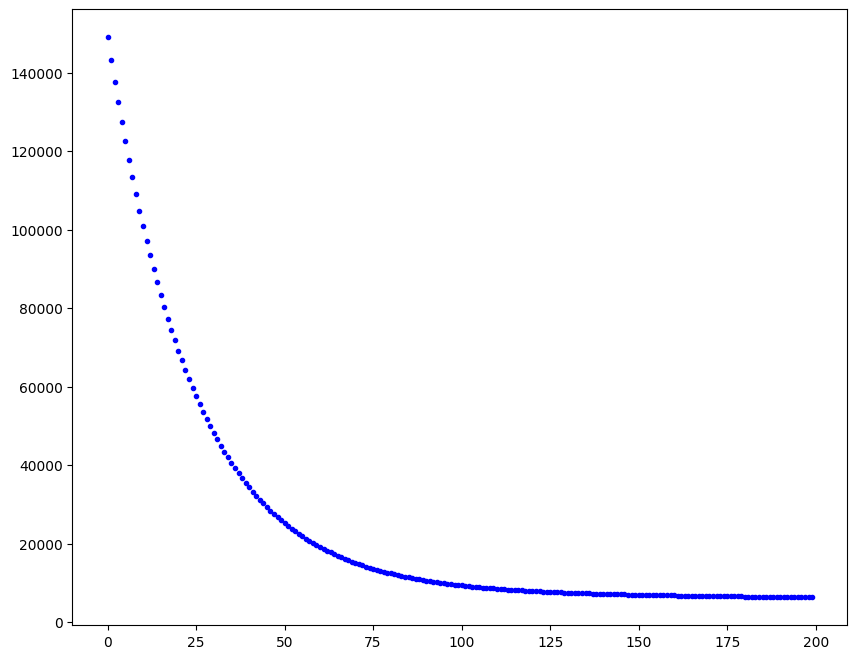

In [10]:
fig,ax = plt.subplots(figsize=(10,8))
ax.plot(range(200), cost_history[:200], 'b.')

# Stochastic Gradient Descent

In Batch Gradient Descent we were considering all the examples for every step of Gradient Descent. But what if our dataset is very huge. Deep learning models crave for data. The more the data the more chances of a model to be good. Suppose our dataset has 5 million examples, then just to take one step the model will have to calculate the gradients of all the 5 million examples. This does not seem an efficient way. To tackle this problem we have Stochastic Gradient Descent. In Stochastic Gradient Descent (SGD), we consider just one example at a time to take a single step.

In [12]:
def stocashtic_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10):
    '''
    X = Matrix of X with added bias units
    y = Vector of Y
    y_pred = Vector of y_pred np.random.randn(j,1)
    learning_rate
    iterations = no of iterations

    Returns the final y_pred vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        cost = 0.0

        for i in range(m):
            rand_ind = np.random.randint(0,m)
            X_i = X[rand_ind, :].reshape(1, X.shape[1])
            y_i = y[rand_ind].reshape(1,1)
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate *(X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

In [13]:
lr = 0.5
n_iter = 50
y_pred = np.random.randn(2, 1)
X_b = np.c_[np.ones((len(X), 1)), X]
y_pred, cost_history = stocashtic_gradient_descent(X_b, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 4.121
y_pred[1]: 2.755
Final error: 41.313


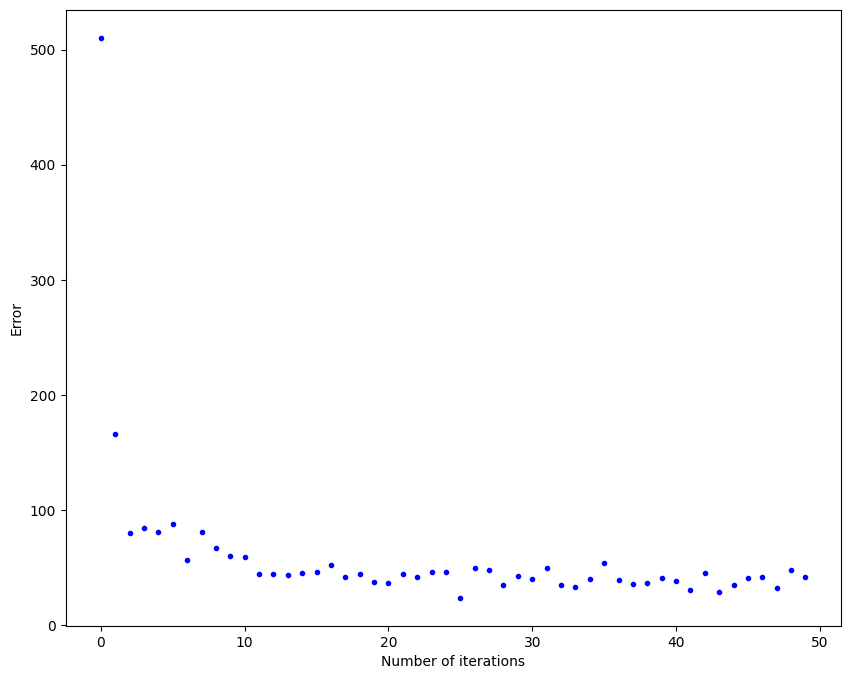

In [14]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
y_pred = np.random.randn(2,1)

ax.plot(range(n_iter), cost_history, 'b.')

# Mini Batch Gradient Descent

We have seen the Batch Gradient Descent. We have also seen the Stochastic Gradient Descent. Batch Gradient Descent can be used for smoother curves. SGD can be used when the dataset is large. Batch Gradient Descent converges directly to minima. SGD converges faster for larger datasets. But, since in SGD we use only one example at a time, we cannot implement the vectorized implementation on it. This can slow down the computations. To tackle this problem, a mixture of Batch Gradient Descent and SGD is used.
Neither we use all the dataset all at once nor we use the single example at a time. We use a batch of a fixed number of training examples which is less than the actual dataset and call it a mini-batch. Doing this helps us achieve the advantages of both the former variants we saw.

In [15]:
def minibatch_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10, batch_size=20):
    '''
    X = Matrix of X without added bias units
    y = Vector of Y
    y_pred = Vector of y_preds np.random.randn(j, 1)
    learning_rate
    iterations = no of iterations

    Returns the final theta vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)
    n_batches = int(m / batch_size)

    for it in range(iterations):
        cost = 0.0
        indices = np.random.permutation(m)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_i = X[i: i + batch_size]
            y_i = y[i: i + batch_size]

            X_i = np.c_[np.ones(len(X_i)), X_i]
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

In [16]:
lr = 0.1
n_iter = 200
y_pred = np.random.randn(2,1)
y_pred, cost_history = minibatch_gradient_descent(X, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 4.148
y_pred[1]: 2.827
Final error: 807.488


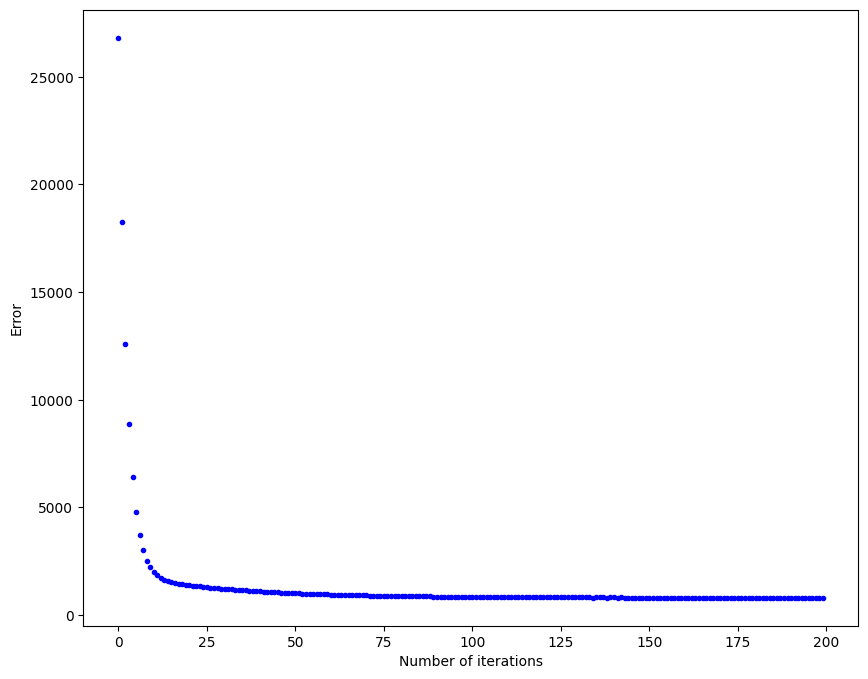

In [17]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
y_pred = np.random.randn(2,1)

ax.plot(range(n_iter), cost_history, 'b.')

Things to try out:

1. Change batch size in mini-batch gradient descent.
2. Test all the three out on real datasets.
3. Compare the effects of changing learning rate by the same amount in Batch GD, SGD and Mini-batch GD.

1.Change batch size in mini-batch gradient descent.


In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
import numpy as np

def load_mnist_data(use_pandas=False, data_path=None):
    """Loads the MNIST dataset for training and testing.

    Args:
        use_pandas (bool, optional): If True, uses pandas to load the data from a CSV file.
            Defaults to False (use TensorFlow's built-in dataset loader).
        data_path (str, optional): Path to the CSV file if use_pandas is True. Defaults to None.

    Returns:
        tuple: A tuple of four NumPy arrays containing the training and testing features
            and labels: (x_train, y_train), (x_test, y_test).
    """

    if use_pandas:
        if data_path is None:
            raise ValueError("Please provide the path to your MNIST CSV file when using pandas.")

        # Load the CSV data
        data = pd.read_csv(data_path)
        # Split features and labels
        x = data.iloc[:, 1:].values.astype('float32')  # All columns except the first
        y = data.iloc[:, 0].values.astype('int')        # First column (labels)

        # Normalize the features
        x /= 255.0

        # Split into training and testing sets (assuming the last 10,000 rows are for testing)
        x_train, x_test = x[:-10000], x[-10000:]
        y_train, y_test = y[:-10000], y[-10000:]

        return (x_train, y_train), (x_test, y_test)

    else:
        # Load the MNIST dataset using TensorFlow
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
        # Preprocess the data
        x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
        x_test = x_test.reshape(-1, 784).astype('float32') / 255.0
        # Return the data
        return (x_train, y_train), (x_test, y_test)
(x_train, y_train), (x_test, y_test) = load_mnist_data(use_pandas=False)  # Change to True and provide path for CSV
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

batch_size = 32
x_val, y_val = x_train[-10000:], y_train[-10000:]
x_train, y_train = x_train[:-10000], y_train[:-10000]

model.fit(x_train, y_train, epochs=10, batch_size=batch_size, validation_data=(x_val, y_val))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8690 - loss: 0.4635 - val_accuracy: 0.9574 - val_loss: 0.1476
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9580 - loss: 0.1369 - val_accuracy: 0.9678 - val_loss: 0.1139
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9742 - loss: 0.0882 - val_accuracy: 0.9718 - val_loss: 0.0960
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9812 - loss: 0.0617 - val_accuracy: 0.9736 - val_loss: 0.0879
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9866 - loss: 0.0455 - val_accuracy: 0.9734 - val_loss: 0.0901
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9899 - loss: 0.0343 - val_accuracy: 0.9763 - val_loss: 0.0781
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9912 - loss: 0.0276 - val_accuracy: 0.9768 - val_loss: 0.0821
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━

2.Test all the three out on real datasets

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
import numpy as np

def load_mnist_data(use_pandas=False, data_path=None):
    """Loads the MNIST dataset for training and testing.

    Args:
        use_pandas (bool, optional): If True, uses pandas to load the data from a CSV file.
            Defaults to False (use TensorFlow's built-in dataset loader).
        data_path (str, optional): Path to the CSV file if use_pandas is True. Defaults to None.

    Returns:
        tuple: A tuple of four NumPy arrays containing the training and testing features
            and labels: (x_train, y_train), (x_test, y_test).
    """

    if use_pandas:
        if data_path is None:
            raise ValueError("Please provide the path to your MNIST CSV file when using pandas.")

        # Load the CSV data
        data = pd.read_csv(data_path)
        # Split features and labels
        x = data.iloc[:, 1:].values.astype('float32')  # All columns except the first
        y = data.iloc[:, 0].values.astype('int')        # First column (labels)

        # Normalize the features
        x /= 255.0

        # Split into training and testing sets (assuming the last 10,000 rows are for testing)
        x_train, x_test = x[:-10000], x[-10000:]
        y_train, y_test = y[:-10000], y[-10000:]

        return (x_train, y_train), (x_test, y_test)

    else:
        # Load the MNIST dataset using TensorFlow
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
        # Preprocess the data
        x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
        x_test = x_test.reshape(-1, 784).astype('float32') / 255.0
        # Return the data
        return (x_train, y_train), (x_test, y_test)

# Load training and testing data
(x_train, y_train), (x_test, y_test) = load_mnist_data(use_pandas=False)  # Change to True and provide path for CSV

# Convert labels to categorical one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

# Define your model architecture
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

# Compile the model with your desired optimizer and loss function
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Specify the batch size during model training
batch_size = 32  # Adjust this to your desired value

# Train the model (assuming you have validation data x_val and y_val)
# For demonstration, let's use a subset of the training data as validation
x_val, y_val = x_train[-10000:], y_train[-10000:]  # Use the last 10,000 samples for validation
x_train, y_train = x_train[:-10000], y_train[:-10000]  # Use the rest for training

model.fit(x_train, y_train, epochs=10, batch_size=batch_size, validation_data=(x_val, y_val))

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8664 - loss: 0.4673 - val_accuracy: 0.9492 - val_loss: 0.1719
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9596 - loss: 0.1361 - val_accuracy: 0.9679 - val_loss: 0.1138
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9741 - loss: 0.0876 - val_accuracy: 0.9701 - val_loss: 0.1014
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9816 - loss: 0.0651 - val_accuracy: 0.9759 - val_loss: 0.0833
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9864 - loss: 0.0461 - val_accuracy: 0.9762 - val_loss: 0.0817
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9878 - loss: 0.0375 - val_accuracy: 0.9759 - val_loss: 0.0849
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9920 - loss: 0.0290 - val_accuracy: 0.9767 - val_loss: 0.0807
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9936 - loss: 0.0231

3.Compare the effects of changing learning rate by the same amount in Batch GD, SGD and Mini-batch GD.

<ipython-input-31-81d1046d1540>:31: RuntimeWarning: overflow encountered in multiply
  gradient_m = -2 * X[i] * (y_pred - y[i])
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
<ipython-input-31-81d1046d1540>:32: RuntimeWarning: overflow encountered in multiply
  gradient_b = -2 * (y_pred - y[i])


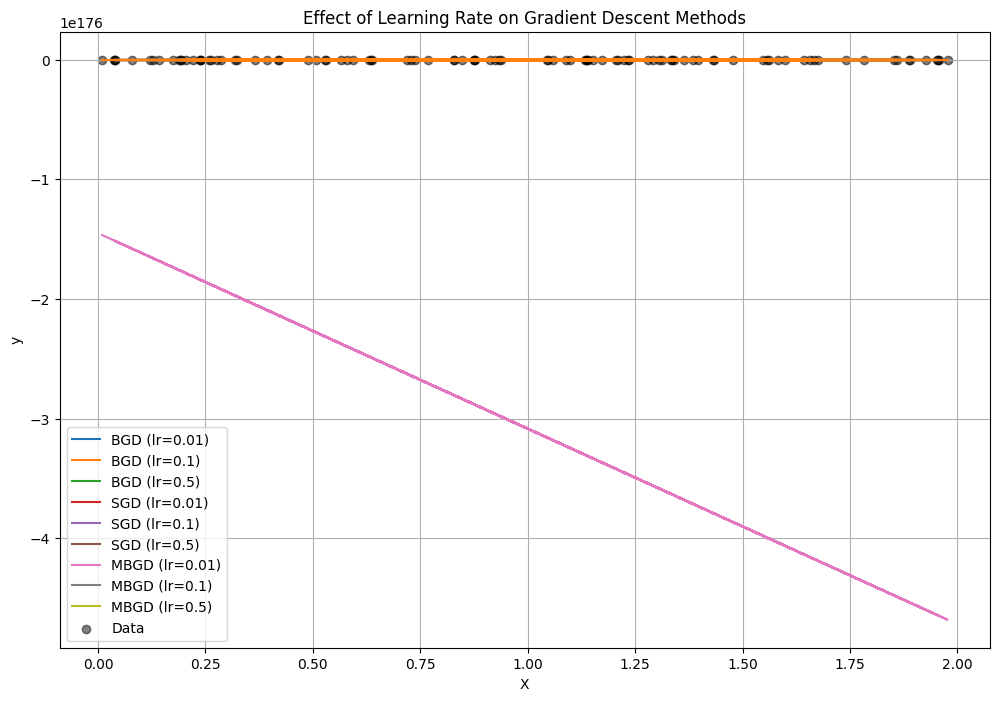

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Learning rates to test
learning_rates = [0.01, 0.1, 0.5]

def batch_gradient_descent(X, y, learning_rate, num_iterations):
    m = np.random.rand(1)
    b = np.random.rand(1)
    n = len(y)
    for _ in range(num_iterations):
        y_pred = m * X + b
        gradient_m = -2/n * np.sum(X * (y_pred - y))
        gradient_b = -2/n * np.sum(y_pred - y)
        m -= learning_rate * gradient_m
        b -= learning_rate * gradient_b
    return m, b

def stochastic_gradient_descent(X, y, learning_rate, num_epochs):
    m = np.random.rand(1)
    b = np.random.rand(1)
    n = len(y)
    for epoch in range(num_epochs):
        for i in range(n):
            y_pred = m * X[i] + b
            gradient_m = -2 * X[i] * (y_pred - y[i])
            gradient_b = -2 * (y_pred - y[i])
            m -= learning_rate * gradient_m
            b -= learning_rate * gradient_b
    return m, b

def mini_batch_gradient_descent(X, y, learning_rate, num_epochs, batch_size):
    m = np.random.rand(1)
    b = np.random.rand(1)
    n = len(y)
    for epoch in range(num_epochs):
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        for i in range(0, n, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]
            y_pred = m * X_batch + b
            gradient_m = -2/len(y_batch) * np.sum(X_batch * (y_pred - y_batch))
            gradient_b = -2/len(y_batch) * np.sum(y_pred - y_batch)
            m -= learning_rate * gradient_m
            b -= learning_rate * gradient_b
    return m, b

# Store results for plotting
results = {'BGD': [], 'SGD': [], 'MBGD': []}

for lr in learning_rates:
    m_bgd, b_bgd = batch_gradient_descent(X, y, lr, 1000)
    results['BGD'].append((m_bgd, b_bgd))

    m_sgd, b_sgd = stochastic_gradient_descent(X, y, lr, 1000)
    results['SGD'].append((m_sgd, b_sgd))

    m_mbgd, b_mbgd = mini_batch_gradient_descent(X, y, lr, 1000, batch_size=10)
    results['MBGD'].append((m_mbgd, b_mbgd))

# Plotting the results
plt.figure(figsize=(12, 8))
for key, value in results.items():
    for i, (m, b) in enumerate(value):
        plt.plot(X, m * X + b, label=f"{key} (lr={learning_rates[i]})")

# Plot the original data
plt.scatter(X, y, color='black', label='Data', alpha=0.5)
plt.title('Effect of Learning Rate on Gradient Descent Methods')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

3.Compare the effects of changing learning rate by the same amount in Batch GD, SGD and Mini-batch GD.

## **Additional Critical Thinking Question**



**Which of the following is TRUE, given the optimal learning rate?**

 (i) Batch gradient descent is always guaranteed to converge to the global optimum of a loss function.
 AnS:- False: While BGD converges to the global optimum for convex loss functions, it is not guaranteed to do so in all cases, especially if the learning rate is not chosen appropriately. If the learning rate is too high, it can lead to divergence.

 (ii) Stochastic gradient descent is always guaranteed to converge to the global optimum of a loss function.

 Ans:-  False: Similar to BGD, SGD can converge to the global optimum for convex loss functions, but it is not guaranteed in all cases. The inherent randomness in SGD can lead to oscillations, and if the learning rate is not managed properly (e.g., decaying over time), it may not converge.


 (iii) For convex loss functions (i.e. with a bowl shape), batch gradient descent is guaranteed to eventually converge to the global optimum while stochastic gradient descent is not.

 Ans :- False:  Both BGD and SGD can converge to the global optimum for convex loss functions, but SGD does so with more variability. The statement incorrectly implies that SGD cannot converge to the global optimum, which is not true for convex functions.

 (iv) For convex loss functions (i.e. with a bowl shape), stochastic gradient descent is guaranteed to eventually converge to the global optimum while batch gradient descent is not.

 Ans:- False:  This statement is also misleading. Both methods can converge to the global optimum for convex loss functions, but SGD may require careful tuning of the learning rate and may oscillate around the optimum.

 (v) For convex loss functions (i.e. with a bowl shape), both stochastic gradient descent and batch gradient descent will eventually converge to the global optimum.

 Ans:- True:  For convex loss functions, both BGD and SGD are guaranteed to converge to the global optimum, assuming appropriate learning rates are used. SGD's convergence may be slower and more erratic due to its stochastic nature, but it can still reach the global optimum.

 (vi) For convex loss functions (i.e. with a bowl shape), neither stochastic gradient descent nor batch gradient descent are guaranteed to converge to the global optimum.

 Ans:- False:  As explained above, both methods can converge to the global optimum for convex loss functions.

Conclusion:
The TRUE statement among the options provided is:

(v) For convex loss functions (i.e., with a bowl shape), both stochastic gradient descent and batch gradient descent will eventually converge to the global optimum.